In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [5]:
grouped_df = df.groupby('Дата', as_index=False)['Количество'].sum()

grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Вывести несколько первых строк сгруппированных данных

In [6]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

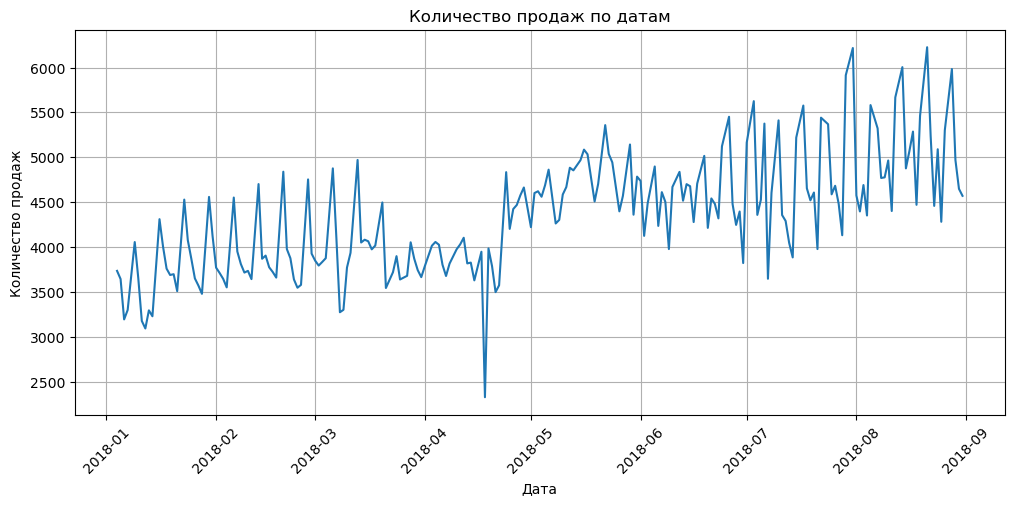

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(grouped_df['Дата'], grouped_df['Количество'])

plt.title('Количество продаж по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')

plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике представлена динамика количества продаж по датам с января по август 2018 года. В январе–марте объем продаж в основном находится в диапазоне примерно от 3000 до 5000 единиц, при этом наблюдаются регулярные резкие колебания. В апреле заметно снижение продаж, а также присутствует самый низкий показатель за весь рассматриваемый период — около 2300 единиц. Начиная с конца апреля и в мае объем продаж в целом увеличивается и чаще находится выше 4000 единиц. В июне–августе наблюдается наиболее высокая и нестабильная динамика: значения часто превышают 5000 единиц, а максимальные показатели достигают примерно 6200 единиц. Таким образом, в течение рассматриваемого периода можно заметить общий рост объема продаж, особенно во второй половине периода, несмотря на значительные ежедневные колебания.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [8]:
max_sales = df['Количество'].max()

print('Максимальное количество продаж:', max_sales)
print(df[df['Количество'] == max_sales])

Максимальное количество продаж: 200
             Дата  Склад   Контрагент Номенклатура  Количество
218822 2018-06-28      1  address_208    product_0         200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [9]:
filtered_df = df[
    (df['Дата'].dt.month.isin([6, 7, 8])) &
    (df['Дата'].dt.weekday == 2) &
    (df['Склад'] == 3)
]

In [10]:
top_products = (
    filtered_df
    .groupby('Номенклатура', as_index=False)['Количество']
    .sum()
    .sort_values('Количество', ascending=False)
)

top_products.head()

,Номенклатура,Количество
1,product_1,2267
12,product_2,2060
0,product_0,1324
17,product_3,914
20,product_6,650


In [11]:
print(top_products.head(1))

  Номенклатура  Количество
1    product_1        2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [16]:
weather = pd.read_csv(
    'weather (3).csv',
    sep=';',
    skiprows=6,
    encoding='utf-8'
)

print(weather.columns.tolist())
print(weather.head())

['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']
                  Местное время в Астане      T     Po    P    Pa  \
31.12.2018 23:00                   -18.4  744.8  780.4  0.5  87.0   
31.12.2018 20:00                   -17.2  744.3  779.6  0.6  86.0   
31.12.2018 17:00                   -14.8  743.7  778.6  0.8  84.0   
31.12.2018 14:00                   -11.2  742.9  777.3  0.5  76.0   
31.12.2018 11:00                   -12.7  742.4  777.1  0.5  79.0   

                                                  U  DD  Ff  ff10  \
31.12.2018 23:00         Ветер, дующий с юго-запада   1 NaN   NaN   
31.12.2018 20:00                Ветер, дующий с юга   1 NaN   NaN   
31.12.2018 17:00  Ветер, дующий с западо-юго-запада   1 NaN   NaN   
31.12.2018 14:00  Ветер, дующий с западо-юго-запада   2 NaN   NaN   
31.12.2018 11:00    Ветер, дующий с юго-юго-во

In [26]:
weather = pd.read_csv(
    'weather (3).csv',
    sep=';',
    skiprows=6,
    encoding='utf-8'
)

print(weather[['Местное время в Астане', 'T']].head())

                  Местное время в Астане      T
31.12.2018 23:00                   -18.4  744.8
31.12.2018 20:00                   -17.2  744.3
31.12.2018 17:00                   -14.8  743.7
31.12.2018 14:00                   -11.2  742.9
31.12.2018 11:00                   -12.7  742.4


In [30]:
weather['Дата'] = pd.to_datetime(
    weather.index,
    dayfirst=True,
    errors='coerce'
).normalize()

weather['T'] = pd.to_numeric(
    weather['Местное время в Астане'],
    errors='coerce'
)

In [31]:
weather_daily = (
    weather.groupby('Дата', as_index=False)['T']
    .mean()
)

print(weather_daily.head())

        Дата        T
0 2018-01-01  -9.4625
1 2018-01-02  -9.5125
2 2018-01-03 -11.4625
3 2018-01-04 -14.0750
4 2018-01-05 -16.8625


In [32]:
merged_df = grouped_df.merge(
    weather_daily,
    on='Дата',
    how='left'
)

print(merged_df.head())

        Дата  Количество        T
0 2018-01-04        3734 -14.0750
1 2018-01-05        3643 -16.8625
2 2018-01-06        3193 -13.3000
3 2018-01-07        3298 -12.7500
4 2018-01-09        4055  -6.2500


In [33]:
print(merged_df.isna().sum())

Дата          0
Количество    0
T             0
dtype: int64


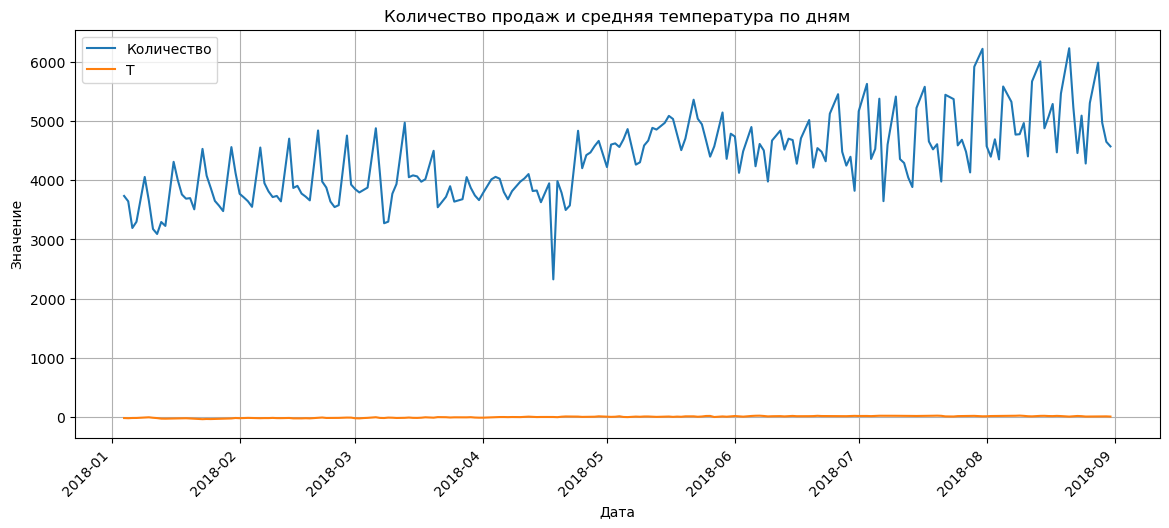

In [34]:
merged_df.plot(
    x='Дата',
    y=['Количество', 'T'],
    figsize=(14, 6)
)

plt.title('Количество продаж и средняя температура по дням')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

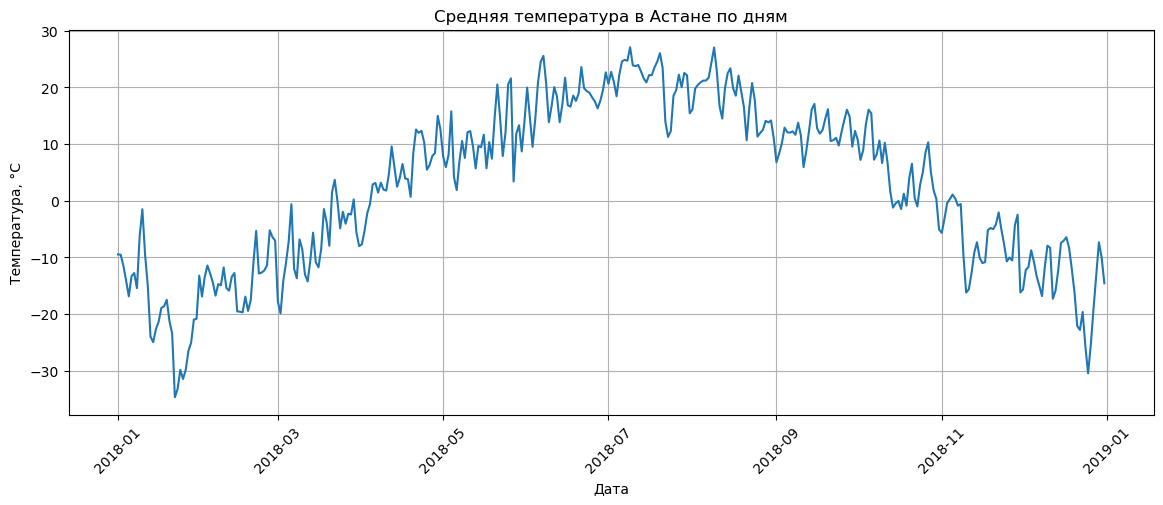

In [35]:
plt.figure(figsize=(14, 5))

plt.plot(
    weather_daily['Дата'],
    weather_daily['T']
)

plt.title('Средняя температура в Астане по дням')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()